# Spotter.ai Machine Learning Engineer Assessment

## Freight Rate Prediction

## Objective

The objective of this assessment is to develop a machine learning model that accurately predicts freight rates using historical shipment data.

The workflow includes:

- Data exploration
- Data cleaning
- Feature engineering
- Model training
- Validation
- Prediction on unseen data
- Generation of December 2025 prediction chart



In [82]:
# ==========================================
# Install Required Libraries
# ==========================================

!pip -q install catboost lightgbm xgboost optuna shap

In [83]:
# ==========================================
# Import Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    KFold,
    cross_val_score
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from catboost import CatBoostRegressor

import os
import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving validation-predictions-template.csv to validation-predictions-template (3).csv


In [87]:
train = pd.read_csv("train-test.csv")
validation = pd.read_csv("validation.csv")
template = pd.read_csv("validation-predictions-template.csv")
december = pd.read_csv("december-chart-inputs.csv")

In [88]:
print("="*60)
print("Training Dataset :", train.shape)

print("="*60)
print("Validation Dataset :", validation.shape)

print("="*60)
print("Prediction Template :", template.shape)

print("="*60)
print("December Dataset :", december.shape)

Training Dataset : (48000, 14)
Validation Dataset : (12000, 13)
Prediction Template : (12000, 2)
December Dataset : (31, 7)


In [89]:
print(train.head())

print()

print(train.info())

print()

print(train.describe(include="all").T)

     load_id        pickup      delivery  pickup_lat  pickup_lon  \
0  TR-000001      Richmond     Baltimore    38.09122   -76.78906   
1  TR-000002      Richmond  Philadelphia    38.09122   -76.78906   
2  TR-000003  Philadelphia     Green Bay    39.22317   -72.96710   
3  TR-000004      Hartford       Atlanta    39.55328   -72.18051   
4  TR-000005        Dallas     Nashville    31.83025   -94.38343   

   delivery_lat  delivery_lon  distance equipment   weight        date  \
0      38.16908     -72.74564     274.3   Dry Van  30658.0  2025-01-01   
1      39.22317     -72.96710     280.5    Reefer  17555.0  2025-01-01   
2      44.30296     -87.52871     967.8   Dry Van  31721.0  2025-01-01   
3      34.84933     -86.28940     965.4   Dry Van  32333.0  2025-01-01   
4      35.29479     -88.08915     541.9    Reefer  35183.0  2025-01-01   

   market_index  quote_signal  posted_rate  
0       0.95684       2.39595       645.41  
1       0.97623       2.43355       679.97  
2       1.0

# Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, identify potential data quality issues, examine feature distributions, and uncover relationships that may improve model performance.

In [90]:
# ==========================================
# Dataset Overview
# ==========================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(train.shape)

print("\n")

print("=" * 60)
print("Column Names")
print("=" * 60)
print(train.columns.tolist())

print("\n")

print("=" * 60)
print("Data Types")
print("=" * 60)
print(train.dtypes)

Dataset Shape
(48000, 14)


Column Names
['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']


Data Types
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object


In [91]:
# ==========================================
# Missing Values
# ==========================================

missing = pd.DataFrame({
    "Missing Values": train.isnull().sum(),
    "Percentage (%)": (train.isnull().sum()/len(train))*100
})

missing = missing.sort_values("Percentage (%)", ascending=False)

missing

,Missing Values,Percentage (%)
market_index,374,0.779167
weight,300,0.625000
delivery,0,0.000000
pickup_lat,0,0.000000
load_id,0,0.000000
pickup,0,0.000000
delivery_lat,0,0.000000
pickup_lon,0,0.000000
distance,0,0.000000
delivery_lon,0,0.000000


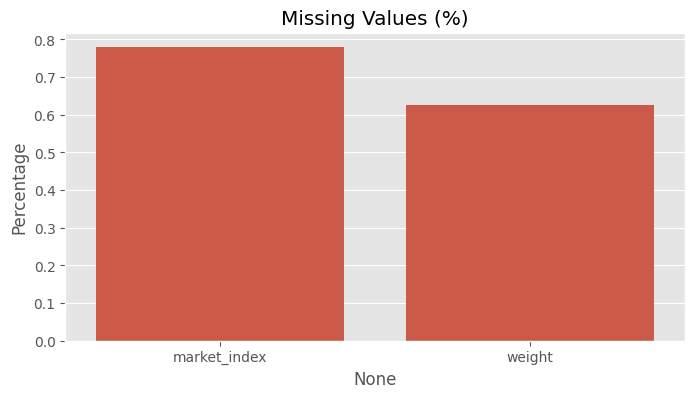

In [92]:
plt.figure(figsize=(8,4))

missing = missing[missing["Missing Values"] > 0]

sns.barplot(
    data=missing,
    x=missing.index,
    y="Percentage (%)"
)

plt.title("Missing Values (%)")
plt.ylabel("Percentage")

plt.show()

In [93]:
duplicates = train.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


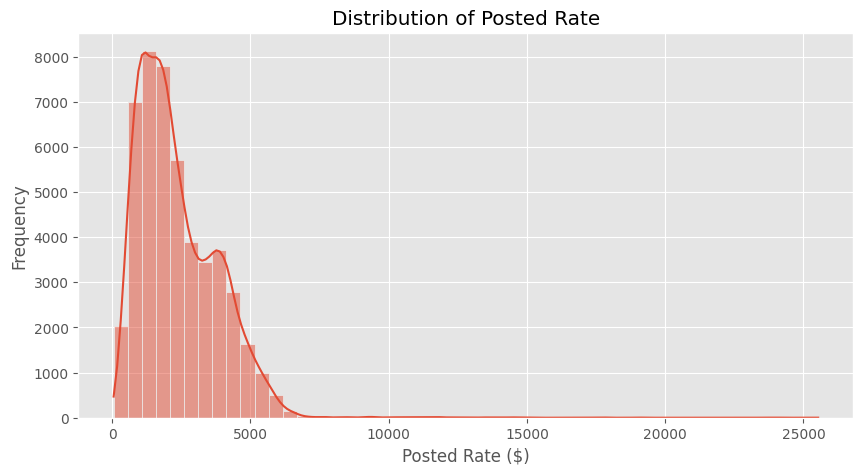

In [94]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["posted_rate"],
    bins=50,
    kde=True
)

plt.title("Distribution of Posted Rate")

plt.xlabel("Posted Rate ($)")

plt.ylabel("Frequency")

plt.show()

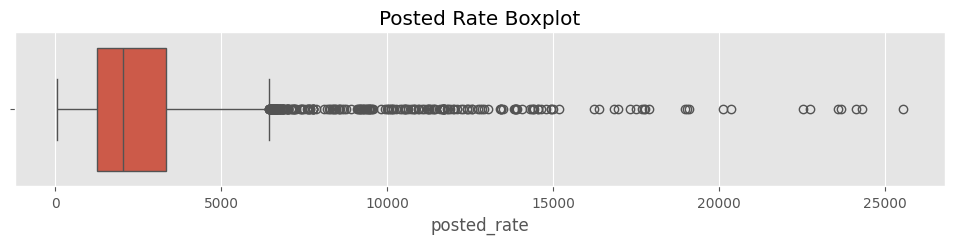

In [95]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=train["posted_rate"]
)

plt.title("Posted Rate Boxplot")

plt.show()

In [96]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0,35.647545,4.315285,28.35765,31.98691,35.29479,39.411040,44.30296
pickup_lon,48000.0,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.285060,-69.50000
delivery_lat,48000.0,35.641175,4.317199,28.35765,31.98691,35.29479,39.411040,44.30296
delivery_lon,48000.0,-90.857310,13.476589,-121.69849,-98.40059,-87.52871,-83.285060,-69.50000
distance,48000.0,1135.856654,728.564416,70.00000,550.40000,953.30000,1645.525000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,25800.00000,31436.50000,37018.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.94967,1.05580,1.219590,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.89103,2.05575,2.221685,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,1251.55500,2030.76000,3330.750000,25533.00000


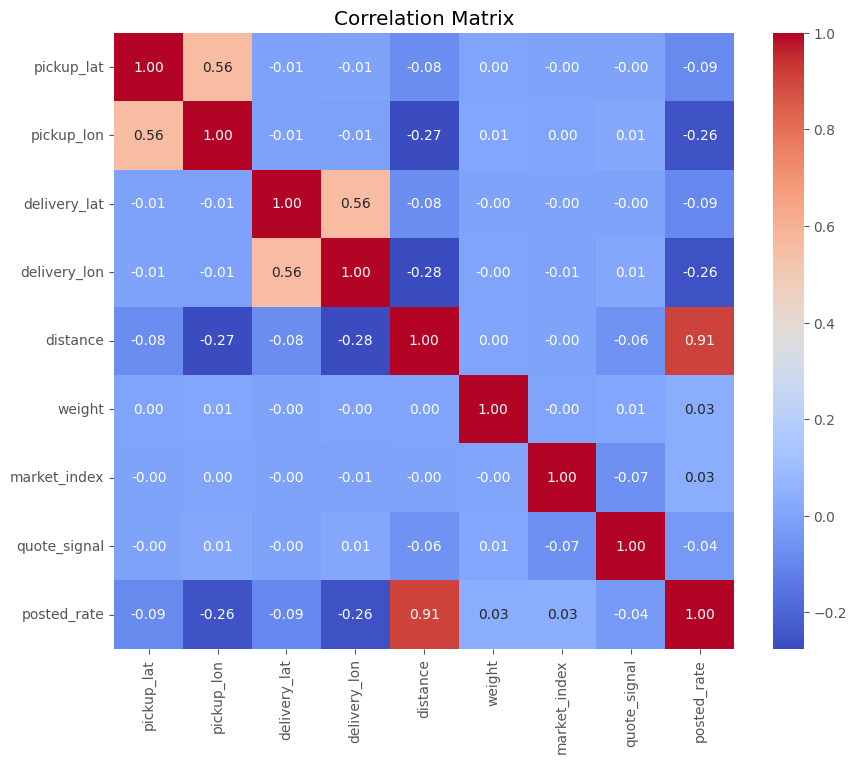

In [97]:
plt.figure(figsize=(10,8))

corr = train.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

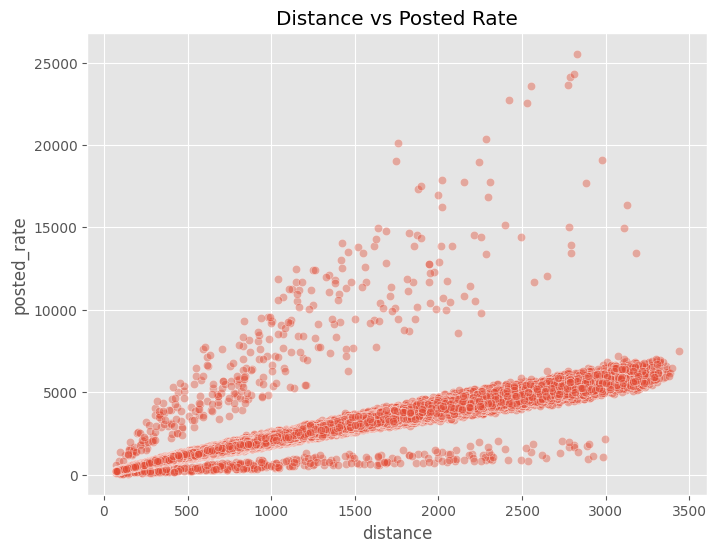

In [98]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=train,
    x="distance",
    y="posted_rate",
    alpha=0.4
)

plt.title("Distance vs Posted Rate")

plt.show()

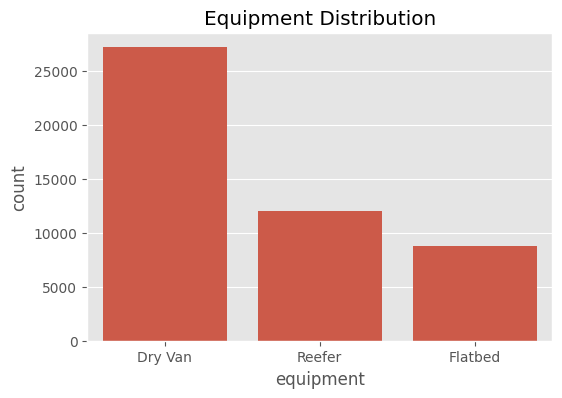

In [99]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="equipment"
)

plt.title("Equipment Distribution")

plt.show()

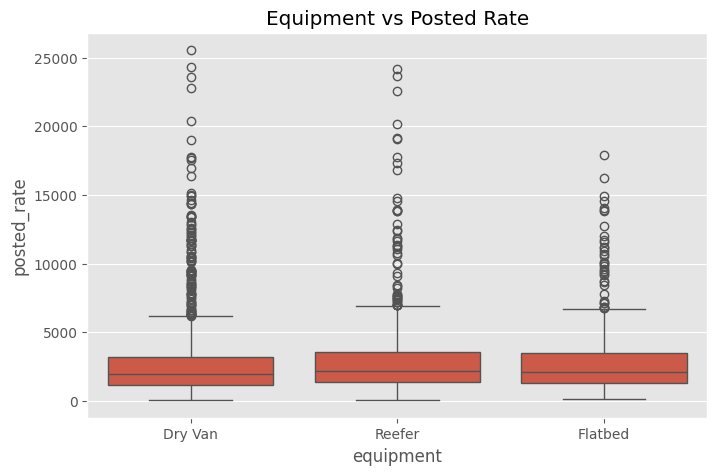

In [100]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x="equipment",
    y="posted_rate"
)

plt.title("Equipment vs Posted Rate")

plt.show()

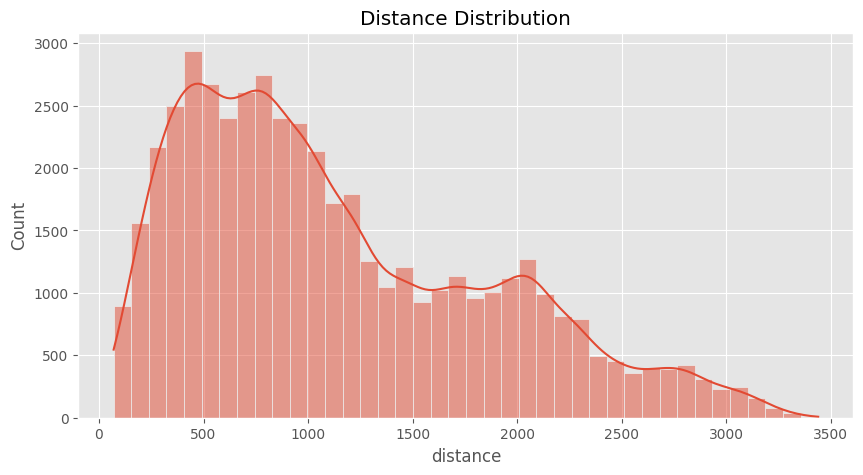

In [101]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["distance"],
    bins=40,
    kde=True
)

plt.title("Distance Distribution")

plt.show()

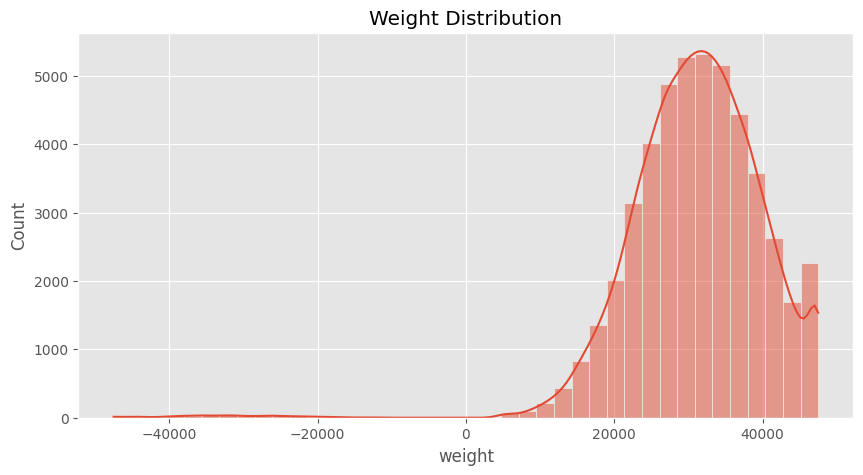

In [102]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["weight"],
    bins=40,
    kde=True
)

plt.title("Weight Distribution")

plt.show()

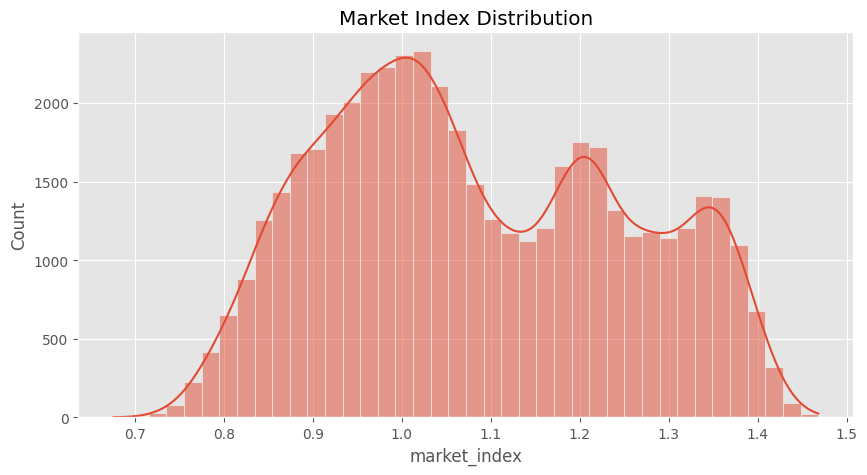

In [103]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["market_index"],
    bins=40,
    kde=True
)

plt.title("Market Index Distribution")

plt.show()

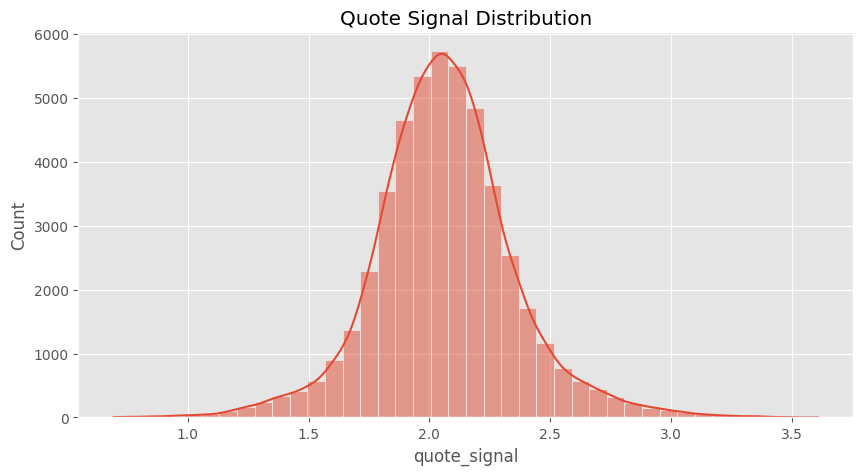

In [104]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["quote_signal"],
    bins=40,
    kde=True
)

plt.title("Quote Signal Distribution")

plt.show()

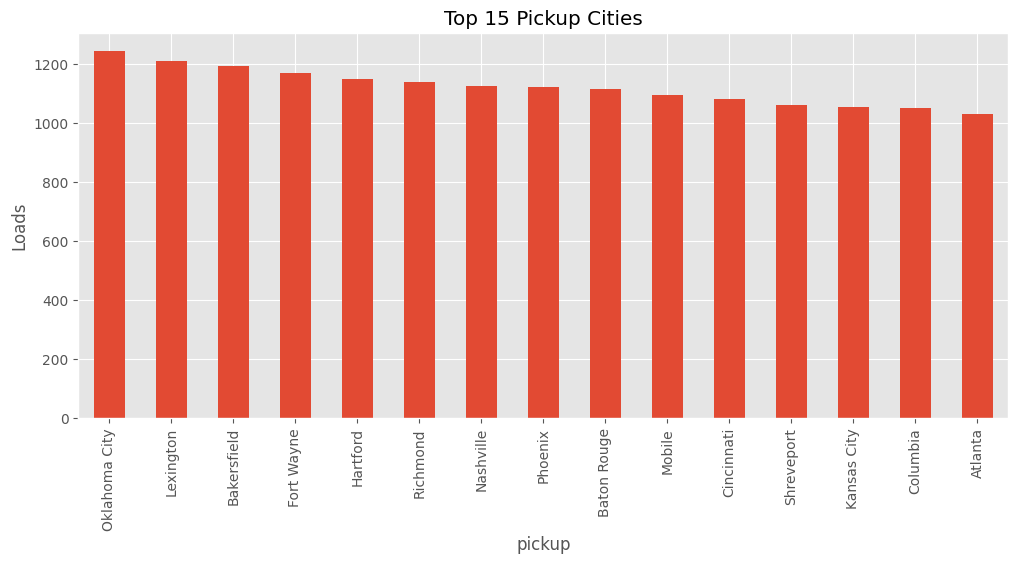

In [105]:
plt.figure(figsize=(12,5))

train["pickup"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Pickup Cities")

plt.ylabel("Loads")

plt.show()

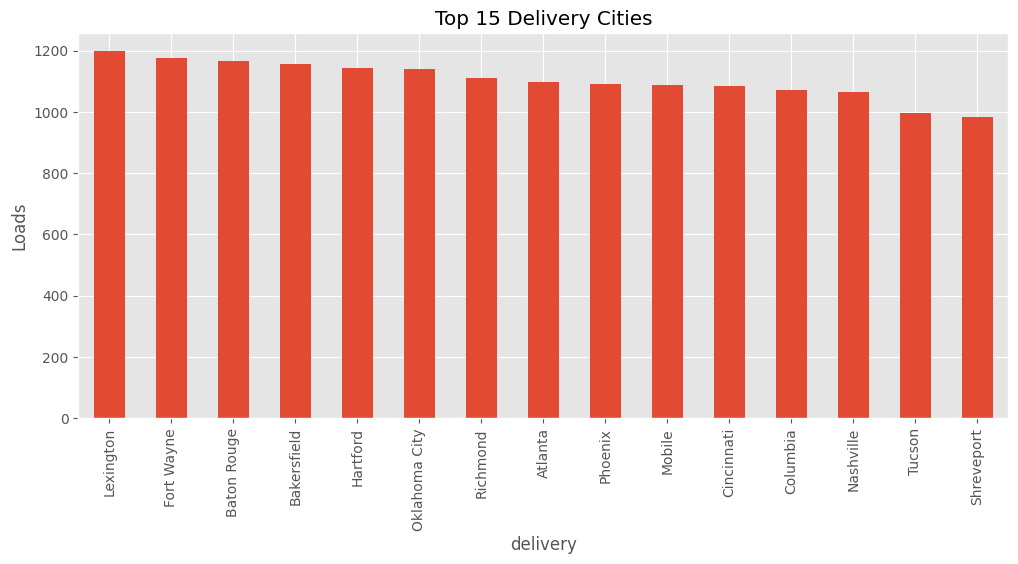

In [106]:
plt.figure(figsize=(12,5))

train["delivery"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Delivery Cities")

plt.ylabel("Loads")

plt.show()

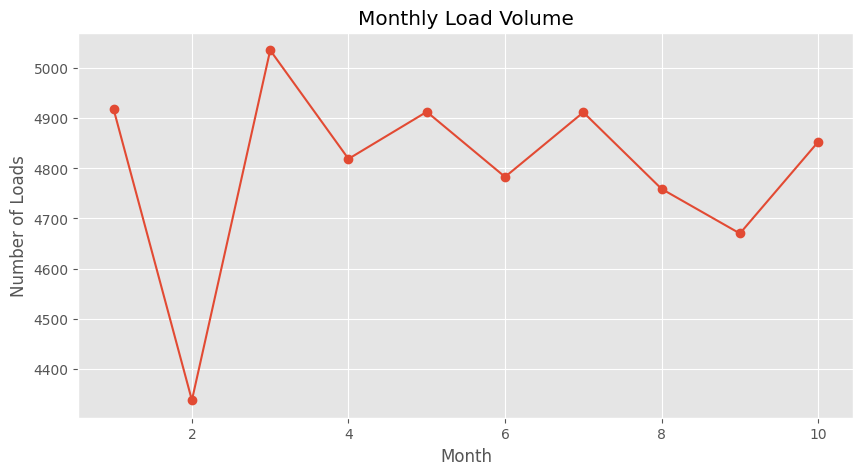

In [107]:
train["date"] = pd.to_datetime(train["date"])

monthly_loads = train.groupby(train["date"].dt.month)["load_id"].count()

plt.figure(figsize=(10,5))

monthly_loads.plot(marker="o")

plt.title("Monthly Load Volume")

plt.xlabel("Month")

plt.ylabel("Number of Loads")

plt.grid(True)

plt.show()

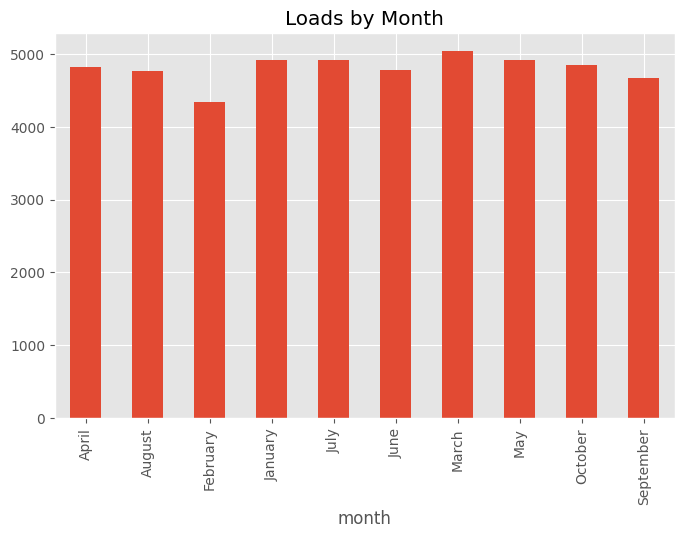

In [108]:
train["month"] = train["date"].dt.month_name()

plt.figure(figsize=(8,5))

train["month"].value_counts().sort_index().plot(kind="bar")

plt.title("Loads by Month")

plt.show()

## Key Findings from EDA

- The dataset contains 48,000 historical freight loads.
- Missing values are limited to `weight` and `market_index`, both affecting less than 1% of the data.
- No duplicate records were identified.
- `distance` shows the strongest positive relationship with the target variable (`posted_rate`).
- Freight rates are right-skewed, with a small number of high-value shipments.
- Equipment type influences freight pricing, with Reefer and Flatbed shipments generally exhibiting higher rates than Dry Van shipments.
- Load volumes remain relatively consistent throughout the year, providing sufficient temporal coverage for model training.

# Data Preprocessing & Feature Engineering

This section prepares the dataset for machine learning by handling missing values, engineering meaningful features, and creating a consistent preprocessing pipeline for both training and inference datasets.

In [109]:
# ==========================================
# Create Working Copies
# ==========================================

train_df = train.copy()
validation_df = validation.copy()
december_df = december.copy()

In [110]:
# ==========================================
# Training Statistics
# ==========================================

WEIGHT_MEDIAN = train_df["weight"].median()
MARKET_MEDIAN = train_df["market_index"].median()

print("Weight Median :", WEIGHT_MEDIAN)
print("Market Index Median :", MARKET_MEDIAN)

Weight Median : 31436.5
Market Index Median : 1.0558


In [111]:
# ==========================================
# Data Preprocessing Function
# ==========================================

def preprocess_data(df, is_training=False):

    df = df.copy()

    # -----------------------------
    # Missing Values
    # -----------------------------

    if "weight" in df.columns:
        df["weight"] = df["weight"].fillna(WEIGHT_MEDIAN)

    if "market_index" in df.columns:
        df["market_index"] = df["market_index"].fillna(MARKET_MEDIAN)

    # -----------------------------
    # Date Features
    # -----------------------------

    df["date"] = pd.to_datetime(df["date"])

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["date"].dt.quarter
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # -----------------------------
    # Route Feature
    # -----------------------------

    if "pickup" in df.columns and "delivery" in df.columns:
        df["route"] = df["pickup"] + "_" + df["delivery"]

    # -----------------------------
    # Geographic Features
    # -----------------------------

    if {"pickup_lat","pickup_lon","delivery_lat","delivery_lon"}.issubset(df.columns):

        df["lat_diff"] = np.abs(df["pickup_lat"] - df["delivery_lat"])
        df["lon_diff"] = np.abs(df["pickup_lon"] - df["delivery_lon"])

    # -----------------------------
    # Interaction Features
    # -----------------------------

    if "distance" in df.columns and "weight" in df.columns:
        df["weight_per_mile"] = df["weight"] / (df["distance"] + 1)

    if {"market_index","distance"}.issubset(df.columns):
        df["market_distance"] = df["market_index"] * df["distance"]

    if {"quote_signal","distance"}.issubset(df.columns):
        df["signal_distance"] = df["quote_signal"] * df["distance"]

    if {"market_index","quote_signal"}.issubset(df.columns):
        df["market_signal"] = df["market_index"] * df["quote_signal"]

    return df

In [112]:
train_df = preprocess_data(train_df, is_training=True)

validation_df = preprocess_data(validation_df)

december_df = preprocess_data(december_df)

In [113]:
print(train_df.shape)
print(validation_df.shape)
print(december_df.shape)

(48000, 28)
(12000, 27)
(31, 16)


In [114]:
def add_frequency_features(df):

    df = df.copy()

    df["pickup_frequency"] = df["pickup"].map(pickup_freq).fillna(0)

    df["delivery_frequency"] = df["delivery"].map(delivery_freq).fillna(0)

    df["route_frequency"] = df["route"].map(route_freq).fillna(0)

    df["equipment_frequency"] = df["equipment"].map(equipment_freq).fillna(0)

    return df

In [115]:
def add_distance_bucket(df):

    df = df.copy()

    bins = [0,250,750,np.inf]

    labels = ["Short","Medium","Long"]

    df["distance_bucket"] = pd.cut(
        df["distance"],
        bins=bins,
        labels=labels
    )

    return df

In [116]:
train_df = add_distance_bucket(train_df)

validation_df = add_distance_bucket(validation_df)

december_df = add_distance_bucket(december_df)

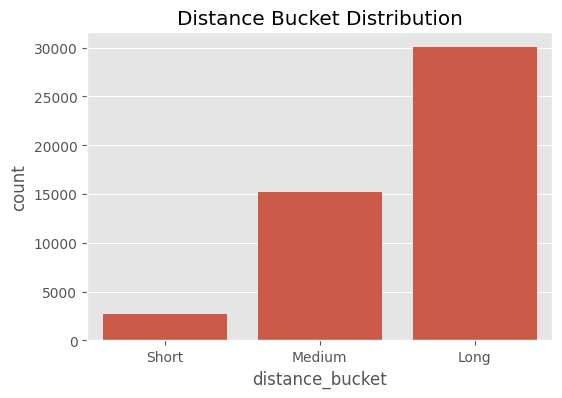

In [117]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train_df,
    x="distance_bucket"
)

plt.title("Distance Bucket Distribution")

plt.show()

In [118]:
print(train_df.shape)
print(validation_df.shape)
print(december_df.shape)

(48000, 29)
(12000, 28)
(31, 17)


In [119]:
# ==========================================
# Target Variable
# ==========================================

TARGET = "posted_rate"

X = train_df.drop(columns=[TARGET])

y = train_df[TARGET]

print(X.shape)
print(y.shape)

(48000, 28)
(48000,)


In [120]:
print(train_df["date"].min())
print(train_df["date"].max())

print(train_df["date"].dt.to_period("M").value_counts().sort_index())

2025-01-01 00:00:00
2025-10-31 00:00:00
date
2025-01    4918
2025-02    4337
2025-03    5036
2025-04    4819
2025-05    4913
2025-06    4783
2025-07    4912
2025-08    4759
2025-09    4670
2025-10    4853
Freq: M, Name: count, dtype: int64


In [121]:
# ==========================================
# Time-Based Train / Validation Split
# ==========================================

train_split = train_df[train_df["date"] < "2025-10-01"].copy()

valid_split = train_df[train_df["date"] >= "2025-10-01"].copy()

print("Training Shape :", train_split.shape)
print("Validation Shape :", valid_split.shape)

Training Shape : (43147, 29)
Validation Shape : (4853, 29)


In [122]:
pickup_freq = train_split["pickup"].value_counts().to_dict()

delivery_freq = train_split["delivery"].value_counts().to_dict()

route_freq = train_split["route"].value_counts().to_dict()

equipment_freq = train_split["equipment"].value_counts().to_dict()

In [123]:
def apply_frequency_features(df):

    df = df.copy()

    df["pickup_frequency"] = df["pickup"].map(pickup_freq).fillna(0)

    df["delivery_frequency"] = df["delivery"].map(delivery_freq).fillna(0)

    df["route_frequency"] = df["route"].map(route_freq).fillna(0)

    df["equipment_frequency"] = df["equipment"].map(equipment_freq).fillna(0)

    return df

In [124]:
train_split = apply_frequency_features(train_split)

valid_split = apply_frequency_features(valid_split)

validation_df = apply_frequency_features(validation_df)

december_df = apply_frequency_features(december_df)

In [125]:
TARGET = "posted_rate"

X_train = train_split.drop(columns=[TARGET])

y_train = train_split[TARGET]

X_valid = valid_split.drop(columns=[TARGET])

y_valid = valid_split[TARGET]

In [126]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [127]:
TARGET = "posted_rate"

categorical_features = [
    "pickup",
    "delivery",
    "equipment",
    "route",
    "distance_bucket"
]

categorical_features = [c for c in categorical_features if c in X_train.columns]

numerical_features = [
    c for c in X_train.columns
    if c not in categorical_features + ["load_id", "date"]
]

print("Categorical Features:", categorical_features)
print("Numerical Features:", len(numerical_features))

Categorical Features: ['pickup', 'delivery', 'equipment', 'route', 'distance_bucket']
Numerical Features: 25


In [128]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [129]:
linear_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['pickup_lat', 'pickup_lon',
                                                   'delivery_lat',
                                                   'delivery_lon', 'distance',
                                                   'weight', 'market_index',
                                                   'quote_signal', 'month',
                                                   'year', 'day', 'dayofweek',
                                                   'weekofyear', 'quarter',
                                                   'is_weekend', 'lat_diff',
                                                   'lon_diff',
                                                   'weight_per_mile',
                                                   'market_distance',
                                                   'signal_distance',
                                                   'market_signal',
                                                   'pickup_frequency',
                                                   'delivery_frequency',
                                                   'route_frequency',
                                                   'equipment_frequency']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['pickup', 'delivery',
                                                   'equipment', 'route',
                                                   'distance_bucket'])])),
                ('model', LinearRegression())])

In [130]:
linear_pred = linear_pipeline.predict(X_valid)

In [131]:
mae = mean_absolute_error(y_valid, linear_pred)

rmse = np.sqrt(mean_squared_error(y_valid, linear_pred))

r2 = r2_score(y_valid, linear_pred)

print("="*40)
print("Linear Regression")
print("="*40)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Linear Regression
MAE : 144.09
RMSE: 652.66
R²  : 0.8177


**CatBoost Model**

In [132]:
cat_features = [
    "pickup",
    "delivery",
    "equipment",
    "route",
    "distance_bucket"
]

cat_features = [c for c in cat_features if c in X_train.columns]

In [133]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(

    iterations=2000,

    learning_rate=0.03,

    depth=8,

    loss_function="RMSE",

    eval_metric="RMSE",

    random_seed=42,

    verbose=200,

    early_stopping_rounds=100
)

In [134]:
X_train = X_train.drop(columns=["load_id"])
X_valid = X_valid.drop(columns=["load_id"])

validation_features = validation_df.drop(columns=["load_id"], errors="ignore")

In [135]:
X_train = X_train.drop(columns=["date"])
X_valid = X_valid.drop(columns=["date"])

validation_features = validation_features.drop(columns=["date"], errors="ignore")
december_features = december_df.drop(columns=["date"], errors="ignore")

In [136]:
cat_features = [
    "pickup",
    "delivery",
    "equipment",
    "route",
    "distance_bucket"
]

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)

In [137]:
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 1446.7188100	test: 1492.9971181	best: 1492.9971181 (0)	total: 239ms	remaining: 7m 57s
200:	learn: 577.0374030	test: 651.7487391	best: 651.7487391 (200)	total: 26.2s	remaining: 3m 54s
400:	learn: 560.7627244	test: 650.6457675	best: 649.8948074 (330)	total: 42.6s	remaining: 2m 49s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 649.8948074
bestIteration = 330

Shrink model to first 331 iterations.


CatBoostRegressor(depth=8, early_stopping_rounds=100, eval_metric='RMSE', iterations=2000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [138]:
cat_pred = cat_model.predict(X_valid)

In [139]:
cat_mae = mean_absolute_error(y_valid, cat_pred)

cat_rmse = np.sqrt(mean_squared_error(y_valid, cat_pred))

cat_r2 = r2_score(y_valid, cat_pred)

print("="*40)
print("CatBoost")
print("="*40)

print(f"MAE : {cat_mae:.2f}")
print(f"RMSE: {cat_rmse:.2f}")
print(f"R²  : {cat_r2:.4f}")

CatBoost
MAE : 136.96
RMSE: 649.89
R²  : 0.8192


In [140]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "CatBoost"],
    "MAE": [mae, cat_mae],
    "RMSE": [rmse, cat_rmse],
    "R2": [r2, cat_r2]
})

results.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,CatBoost,136.961432,649.894812,0.819231
0,Linear Regression,144.093259,652.662267,0.817689


### Model Selection

CatBoost achieved the best validation performance with the lowest MAE and RMSE while also providing the highest R² score.

Therefore, CatBoost was selected as the final model for generating predictions on the unseen validation dataset.

Final Model Training

After selecting CatBoost based on the time-based validation results, the final model is retrained using the complete training dataset (48,000 historical loads).

Using all available historical data allows the model to learn from the maximum amount of information before generating predictions for the unseen validation dataset and the fixed December prediction set.

In [141]:
# ==========================================
# Frequency Encoding (Final Training)
# ==========================================

pickup_freq = train_df["pickup"].value_counts().to_dict()

delivery_freq = train_df["delivery"].value_counts().to_dict()

route_freq = train_df["route"].value_counts().to_dict()

equipment_freq = train_df["equipment"].value_counts().to_dict()

In [142]:
train_df = add_frequency_features(train_df)

validation_df = add_frequency_features(validation_df)

december_df = add_frequency_features(december_df)

In [143]:
TARGET = "posted_rate"

X_final = train_df.drop(columns=[TARGET])

y_final = train_df[TARGET]

In [144]:
cat_features = [
    "pickup",
    "delivery",
    "equipment",
    "route",
    "distance_bucket"
]

for col in cat_features:
    X_final[col] = X_final[col].astype(str)

    validation_df[col] = validation_df[col].astype(str)

    december_df[col] = december_df[col].astype(str)

In [145]:
drop_cols = ["load_id", "date"]

X_final = X_final.drop(columns=drop_cols)

X_validation = validation_df.drop(columns=drop_cols)

X_december = december_df.drop(columns=["date"])

In [146]:
from catboost import CatBoostRegressor

cat_model_final = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

In [147]:
cat_feature_indices = [
    X_final.columns.get_loc(col)
    for col in cat_features
]

In [148]:
cat_model_final.fit(
    X_final,
    y_final,
    cat_features=cat_features
)

0:	learn: 1426.8705912	total: 217ms	remaining: 3m 36s
100:	learn: 582.6374991	total: 10.5s	remaining: 1m 33s
200:	learn: 569.3079031	total: 21.3s	remaining: 1m 24s
300:	learn: 559.3589934	total: 31.6s	remaining: 1m 13s
400:	learn: 550.9464696	total: 42.5s	remaining: 1m 3s
500:	learn: 542.9981713	total: 51.9s	remaining: 51.6s
600:	learn: 535.6549572	total: 1m 2s	remaining: 41.6s
700:	learn: 528.2538841	total: 1m 13s	remaining: 31.5s
800:	learn: 522.1048505	total: 1m 24s	remaining: 21.1s
900:	learn: 514.1591061	total: 1m 36s	remaining: 10.6s
999:	learn: 507.3572218	total: 1m 45s	remaining: 0us


CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [149]:
cat_model_final.save_model("catboost_final_model.cbm")

print("Final model saved successfully.")

Final model saved successfully.


Generate Predictions for validation.csv

In [150]:
print(cat_features)

print(X_final.columns.equals(X_validation.columns))

for i, col in enumerate(X_final.columns):
    print(i, col)

for i, col in enumerate(X_validation.columns):
    print(i, col)

['pickup', 'delivery', 'equipment', 'route', 'distance_bucket']
False
0 pickup
1 delivery
2 pickup_lat
3 pickup_lon
4 delivery_lat
5 delivery_lon
6 distance
7 equipment
8 weight
9 market_index
10 quote_signal
11 month
12 year
13 day
14 dayofweek
15 weekofyear
16 quarter
17 is_weekend
18 route
19 lat_diff
20 lon_diff
21 weight_per_mile
22 market_distance
23 signal_distance
24 market_signal
25 distance_bucket
26 pickup_frequency
27 delivery_frequency
28 route_frequency
29 equipment_frequency
0 pickup
1 delivery
2 pickup_lat
3 pickup_lon
4 delivery_lat
5 delivery_lon
6 distance
7 equipment
8 weight
9 market_index
10 quote_signal
11 year
12 month
13 day
14 dayofweek
15 weekofyear
16 quarter
17 is_weekend
18 route
19 lat_diff
20 lon_diff
21 weight_per_mile
22 market_distance
23 signal_distance
24 market_signal
25 distance_bucket
26 pickup_frequency
27 delivery_frequency
28 route_frequency
29 equipment_frequency


In [151]:
FEATURE_COLUMNS = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "quarter",
    "is_weekend",
    "route",
    "lat_diff",
    "lon_diff",
    "weight_per_mile",
    "market_distance",
    "signal_distance",
    "market_signal",
    "distance_bucket",
    "pickup_frequency",
    "delivery_frequency",
    "route_frequency",
    "equipment_frequency"
]

In [153]:
X_final = train_df[FEATURE_COLUMNS].copy()

X_validation = validation_df[FEATURE_COLUMNS].copy()



In [154]:
# ==========================================
# Generate Predictions
# ==========================================

validation_predictions = cat_model_final.predict(X_validation)

print(f"Generated {len(validation_predictions)} predictions.")

Generated 12000 predictions.


In [155]:
prediction_df = pd.DataFrame({
    "Prediction": validation_predictions
})

prediction_df.describe()

,Prediction
count,12000.000000
mean,2434.959493
std,1423.802254
min,135.950136
25%,1307.345287
50%,2084.096777
75%,3473.466268
max,8983.185440


In [156]:
submission = pd.DataFrame({
    "load_id": validation_df["load_id"],
    "predicted_rate": validation_predictions
})

In [157]:
submission.head()

,load_id,predicted_rate
0,TE-000001,874.421065
1,TE-000002,5165.598326
2,TE-000003,5796.760944
3,TE-000004,3920.511484
4,TE-000005,1868.507398


In [158]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   load_id         12000 non-null  object 
 1   predicted_rate  12000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 187.6+ KB


In [159]:
submission.to_csv(
    "validation_predictions.csv",
    index=False
)

print("validation_predictions.csv saved successfully.")

validation_predictions.csv saved successfully.


In [160]:
print(submission.shape)

print(submission.columns.tolist())

print(submission["predicted_rate"].isnull().sum())

print((submission["predicted_rate"] <= 0).sum())

(12000, 2)
['load_id', 'predicted_rate']
0
0


December 2025 Predictions

The assessment requires generating predictions for a fixed freight lane throughout December 2025.

The same trained CatBoost model is used to predict freight rates for each day, keeping all shipment characteristics fixed except the shipment date.

In [161]:
print(X_final.shape)
print(X_validation.shape)
print(X_december.shape)

print(X_december.columns.tolist())

(48000, 30)
(12000, 30)
(31, 20)
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'predicted_rate', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter', 'is_weekend', 'route', 'weight_per_mile', 'distance_bucket', 'pickup_frequency', 'delivery_frequency', 'route_frequency', 'equipment_frequency']


In [162]:
X_final = train_df[FEATURE_COLUMNS].copy()

X_validation = validation_df[FEATURE_COLUMNS].copy()



In [164]:
print(train_df.columns.tolist())
print(december_df.columns.tolist())

['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate', 'month', 'year', 'day', 'dayofweek', 'weekofyear', 'quarter', 'is_weekend', 'route', 'lat_diff', 'lon_diff', 'weight_per_mile', 'market_distance', 'signal_distance', 'market_signal', 'distance_bucket', 'pickup_frequency', 'delivery_frequency', 'route_frequency', 'equipment_frequency']
['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter', 'is_weekend', 'route', 'weight_per_mile', 'distance_bucket', 'pickup_frequency', 'delivery_frequency', 'route_frequency', 'equipment_frequency']


In [165]:
# ==========================================
# Create City Coordinate Lookup
# ==========================================

pickup_lookup = (
    train_df[
        ["pickup", "pickup_lat", "pickup_lon"]
    ]
    .drop_duplicates(subset="pickup")
    .set_index("pickup")
)

delivery_lookup = (
    train_df[
        ["delivery", "delivery_lat", "delivery_lon"]
    ]
    .drop_duplicates(subset="delivery")
    .set_index("delivery")
)

In [166]:
# Pickup Coordinates

december_df["pickup_lat"] = december_df["pickup"].map(
    pickup_lookup["pickup_lat"]
)

december_df["pickup_lon"] = december_df["pickup"].map(
    pickup_lookup["pickup_lon"]
)

# Delivery Coordinates

december_df["delivery_lat"] = december_df["delivery"].map(
    delivery_lookup["delivery_lat"]
)

december_df["delivery_lon"] = december_df["delivery"].map(
    delivery_lookup["delivery_lon"]
)

In [167]:
print(december_df[
    [
        "pickup",
        "pickup_lat",
        "pickup_lon",
        "delivery",
        "delivery_lat",
        "delivery_lon"
    ]
].head())

      pickup  pickup_lat  pickup_lon    delivery  delivery_lat  delivery_lon
0  Lexington    36.99152   -84.99876  Fort Wayne      41.31561     -85.36206
1  Lexington    36.99152   -84.99876  Fort Wayne      41.31561     -85.36206
2  Lexington    36.99152   -84.99876  Fort Wayne      41.31561     -85.36206
3  Lexington    36.99152   -84.99876  Fort Wayne      41.31561     -85.36206
4  Lexington    36.99152   -84.99876  Fort Wayne      41.31561     -85.36206


In [168]:
december_df["lat_diff"] = (
    december_df["pickup_lat"]
    -
    december_df["delivery_lat"]
).abs()

december_df["lon_diff"] = (
    december_df["pickup_lon"]
    -
    december_df["delivery_lon"]
).abs()

In [169]:
market_index_value = train_df["market_index"].median()

quote_signal_value = train_df["quote_signal"].median()

december_df["market_index"] = market_index_value

december_df["quote_signal"] = quote_signal_value

In [170]:
december_df["market_distance"] = (
    december_df["market_index"]
    *
    december_df["distance"]
)

december_df["signal_distance"] = (
    december_df["quote_signal"]
    *
    december_df["distance"]
)

december_df["market_signal"] = (
    december_df["market_index"]
    *
    december_df["quote_signal"]
)

In [171]:
required_cols = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "market_index",
    "quote_signal",
    "lat_diff",
    "lon_diff",
    "market_distance",
    "signal_distance",
    "market_signal"
]

print(december_df[required_cols].isnull().sum())

pickup_lat         0
pickup_lon         0
delivery_lat       0
delivery_lon       0
market_index       0
quote_signal       0
lat_diff           0
lon_diff           0
market_distance    0
signal_distance    0
market_signal      0
dtype: int64


In [172]:
FEATURE_COLUMNS = X_final.columns.tolist()

X_december = december_df[FEATURE_COLUMNS].copy()

In [173]:
cat_features = [
    "pickup",
    "delivery",
    "equipment",
    "route",
    "distance_bucket"
]

for col in cat_features:
    X_december[col] = X_december[col].astype(str)

In [174]:
FEATURE_COLUMNS = [
    "pickup",
    "delivery",
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "equipment",
    "weight",
    "market_index",
    "quote_signal",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "quarter",
    "is_weekend",
    "route",
    "lat_diff",
    "lon_diff",
    "weight_per_mile",
    "market_distance",
    "signal_distance",
    "market_signal",
    "distance_bucket",
    "pickup_frequency",
    "delivery_frequency",
    "route_frequency",
    "equipment_frequency"
]

In [175]:
X_december = december_df[FEATURE_COLUMNS].copy()

In [176]:
cat_features = [
    "pickup",
    "delivery",
    "equipment",
    "route",
    "distance_bucket"
]

for col in cat_features:
    X_december[col] = X_december[col].astype(str)

In [178]:
from catboost import CatBoostRegressor

cat_model_december = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=False
)

In [179]:
cat_model_december.fit(
    X_final,
    y_final,
    cat_features=cat_feature_indices
)

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [180]:
december_predictions = cat_model_december.predict(X_december)

print(len(december_predictions))

31


In [181]:
december_predictions = cat_model_december.predict(X_december)

print(len(december_predictions))

31


In [182]:
# ==========================================
# Add Predictions
# ==========================================

december_df["predicted_rate"] = december_predictions

In [183]:
# ==========================================
# Create Final December File
# ==========================================

december_submission = december_df[
    [
        "pickup",
        "delivery",
        "distance",
        "equipment",
        "weight",
        "date",
        "predicted_rate"
    ]
].copy()

In [184]:
december_submission.to_csv(
    "december_chart_inputs.csv",
    index=False
)

print("December prediction file saved!")

December prediction file saved!


In [187]:
!python score.py \
--predictions validation_predictions.csv \
--december-predictions december_chart_inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


In [188]:
from google.colab import files

files.download("scorer_results/candidate_december.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>